# Phân tích mức ảnh hưởng giao thông của sự cố tại California và Texas

## Phạm vi triển khai: hợp đồng dữ liệu, split chung, baseline phân lớp, luật kết hợp và đối chiếu rules-model

Notebook này bắt đầu từ kết quả tiền xử lý đã được duyệt ở Bài 1. Mục tiêu không phải lặp lại bài tập kỹ thuật mà là tạo một tập đánh giá chung theo `ID`, sau đó kiểm tra phân lớp và luật kết hợp trên cùng các vụ tai nạn.

### Câu hỏi dẫn dắt được hỗ trợ

- **Q1:** Trong các sự cố đã được ghi nhận tại California và Texas, tổ hợp điều kiện nào liên hệ với tỷ lệ Severity 3-4 cao hơn, và xu hướng có nhất quán theo nguồn, bang và thời kỳ không?
- **Q2:** Từ thông tin có thể biết khi sự cố được ghi nhận, có thể nhận diện sự cố có mức gián đoạn giao thông cao đến đâu và mô hình thường bỏ sót nhóm nào?
- **Q3:** Luật kết hợp và mô hình phân lớp cho bằng chứng đồng hướng, bổ sung hay mâu thuẫn ở nhóm nào sau khi xét thiên lệch nguồn và thời gian?

`is_severe`/`MucDo_Nang` được định nghĩa là `Severity >= 3`. Severity đo mức ảnh hưởng đến luồng giao thông, không đo thương vong. Mọi kết quả là liên hệ quan sát trong mẫu CA/TX, không phải bằng chứng nhân quả.

## 0. Môi trường, hợp đồng dữ liệu và kiểm tra đầu vào

Nguồn duy nhất là `accidents_preprocessed.csv` vì tệp này còn khóa `ID` và chưa impute toàn bộ feature trước split. `Distance(mi)` bị loại vì mô tả phạm vi đường đã bị ảnh hưởng, không phù hợp dự báo sớm. 7.236 thời điểm bị mất trong snapshot Bài 1 được giữ là missing rõ ràng; không gán thành ngày thường.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

from do_an.analysis_core import (
    ARTIFACT_DIR,
    CLASSIFICATION_FEATURES,
    FIGURE_DIR,
    attach_split,
    create_bias_audit,
    create_common_split,
    integrate_rules_and_model,
    load_source_data,
    mine_training_rules,
    run_baseline_classification,
    write_environment_lock,
)

pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 120)

data = load_source_data()
environment_path = write_environment_lock()

bias_audit = create_bias_audit(data)
input_summary = pd.DataFrame({
    'chỉ tiêu': ['Số sự kiện', 'Phạm vi bang', 'ID thiếu', 'ID duy nhất', 'Tỷ lệ Severity 3-4', 'Thời gian thiếu', 'Số feature phân lớp'],
    'giá trị': [len(data), ', '.join(sorted(data['State'].unique())), data['ID'].isna().sum(), data['ID'].nunique(), data['is_severe'].mean(), data['Start_Time'].isna().sum(), len(CLASSIFICATION_FEATURES)],
})
display(input_summary)
display(data['Severity'].value_counts().sort_index().rename('số sự kiện').to_frame())
display(bias_audit[bias_audit['dimension'].isin(['Source', 'State'])].style.format({'severe_rate': '{:.2%}'}))
print('Environment lock:', environment_path.relative_to(Path.cwd()))

,chỉ tiêu,giá trị
0,Số sự kiện,80000
1,Phạm vi bang,"CA, TX"
2,ID thiếu,0
3,ID duy nhất,80000
4,Tỷ lệ Severity 3-4,0.176825
5,Thời gian thiếu,7236
6,Số feature phân lớp,21


,số sự kiện
Severity,
1,520
2,65334
3,13439
4,707


,dimension,stratum,n_events,n_severe,severe_rate
0,Source,Source1,45609,1987,4.36%
1,Source,Source2,32512,11496,35.36%
2,Source,Source3,1879,663,35.28%
3,State,CA,59903,9798,16.36%
4,State,TX,20097,4348,21.64%


Environment lock: artifacts\environment.lock.txt


## 1. Split chung theo ID

Split 80/20 được stratify theo bốn lớp `Severity` với seed 42. Artifact này là hợp đồng dùng chung cho phân lớp, luật kết hợp và các phần tiếp theo; không kỹ thuật nào được tự chia lại dữ liệu.

In [2]:
split, split_distribution = create_common_split(data)
data_with_split = attach_split(data, split)
display(split_distribution.style.format({'severe_rate': '{:.4%}'}))

assert split['ID'].is_unique
assert split['split'].notna().all()
assert set(split['split']) == {'train', 'test'}
assert len(split) == len(data)
print('Đã lưu:', ARTIFACT_DIR / 'split_us_accidents.csv')

,split,n_events,Severity_1,Severity_2,Severity_3,Severity_4,severe_3_4,severe_rate
0,test,16000,104,13067,2688,141,2829,17.6813%
1,train,64000,416,52267,10751,566,11317,17.6828%


Đã lưu: C:\Study\DataMining\data_mining_project\nhom-3-do-an\artifacts\split_us_accidents.csv


## 2. Baseline phân lớp không rò rỉ dữ liệu

Mô hình bốn lớp được giữ làm nền kỹ thuật. Mô hình chính cho tổng hợp dự báo trực tiếp `is_severe` (Severity 3-4), được chọn bằng average precision qua 5-fold stratified CV trên train. Median imputation, scaling và calibration chỉ fit trên train; test không tham gia lựa chọn.

,model,best_cv_average_precision,average_precision,balanced_accuracy,precision_severe,recall_severe,f1_severe,brier_severe
2,Decision Tree balanced,0.3535,0.3668,0.6689,0.3006,0.6752,0.4160,0.1290
1,Logistic Regression balanced,0.2723,0.2794,0.6345,0.2526,0.7381,0.3764,-
0,Dummy - prior,-,0.1768,0.5000,0.0000,0.0000,0.0000,-


,model,best_cv_f1_macro,accuracy,balanced_accuracy,f1_macro,recall_s1,recall_s2,recall_s3,recall_s4
0,Decision Tree balanced,0.2559,0.4486,0.4143,0.2558,0.4327,0.4345,0.5275,0.2624
1,Dummy - most frequent,-,0.8167,0.2500,0.2248,0.0000,1.0000,0.0000,0.0000
2,Logistic Regression balanced,0.2123,0.3658,0.3614,0.2183,0.4231,0.3243,0.5778,0.1206


,giá trị
analysis_target,is_severe = 1 khi Severity thuộc 3-4
selected_model,Decision Tree balanced
selection_rule,Average precision CV cao nhất trên train
binary_logistic_best_params,{'model__C': 10.0}
binary_logistic_best_cv_average_precision,0.272288
binary_tree_best_params,"{'model__max_depth': 12, 'model__min_samples_leaf': 100}"
binary_tree_best_cv_average_precision,0.353519
multiclass_selected_model,Decision Tree balanced
multiclass_selection_rule,F1-macro CV cao nhất trên train
multiclass_logistic_best_params,{'model__C': 1.0}


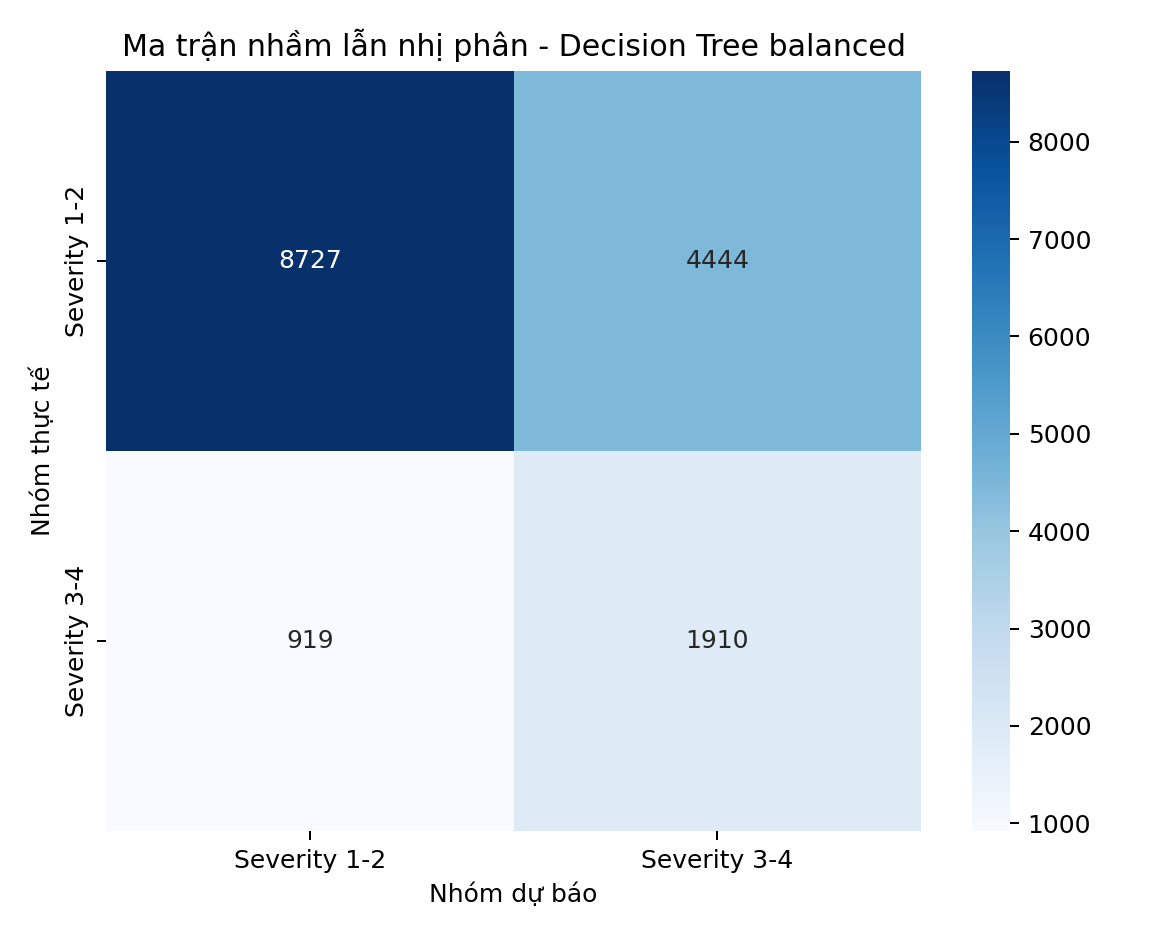

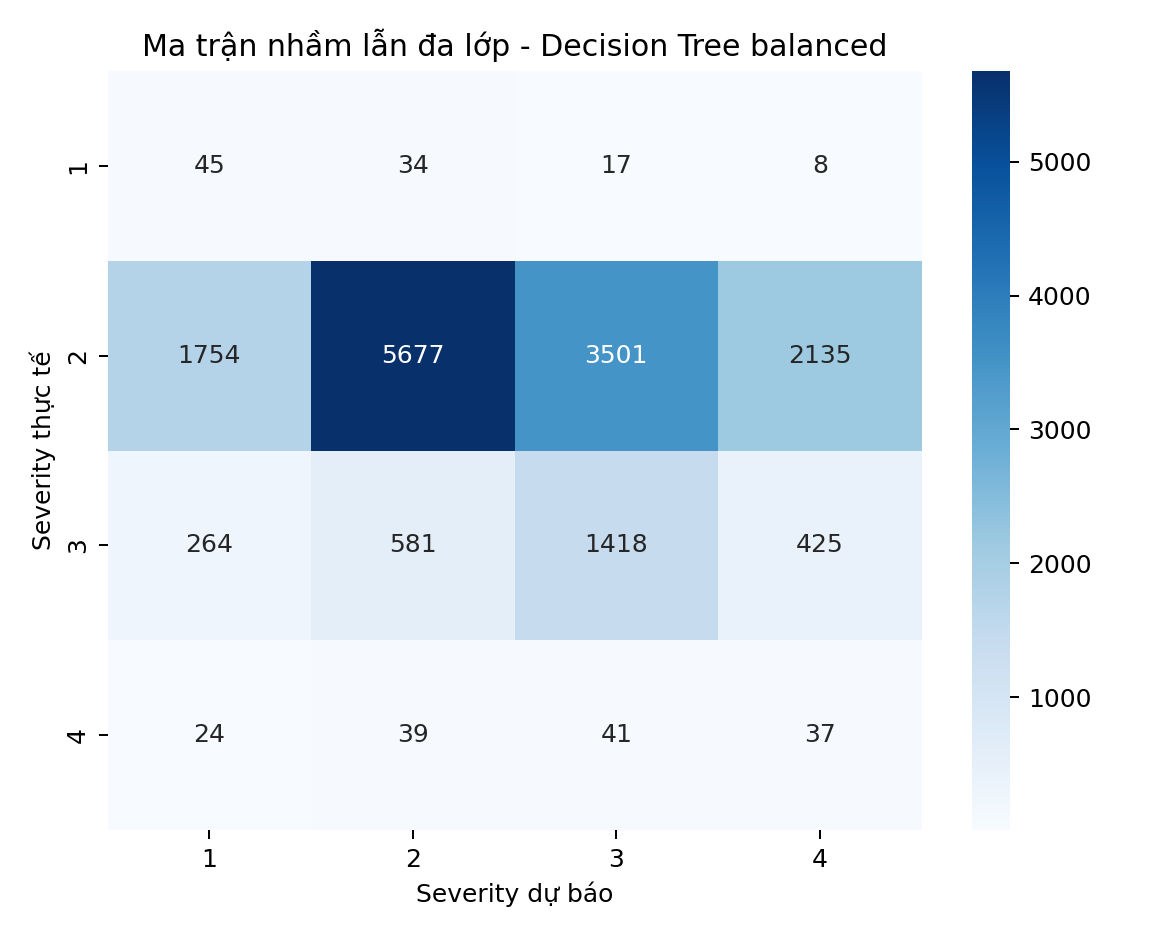

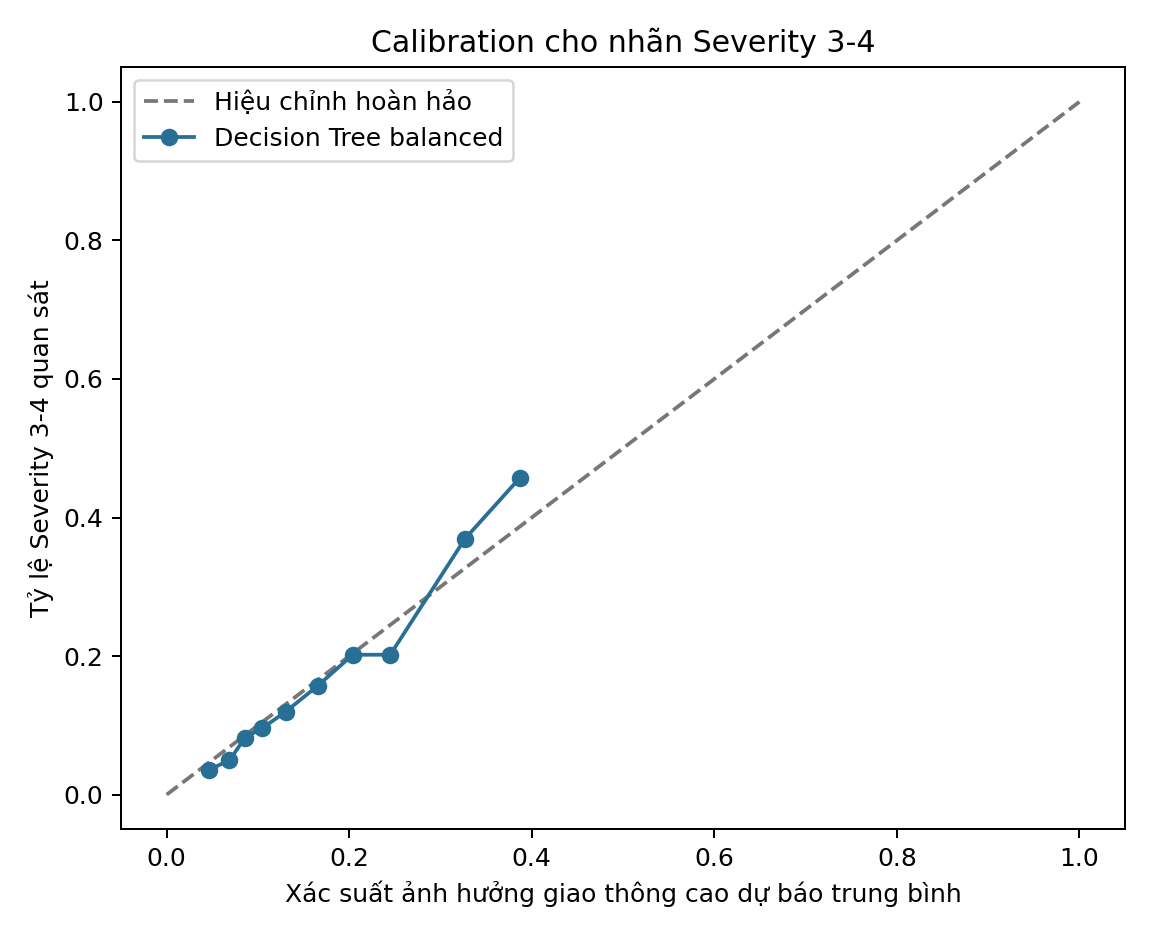

False negative severe: 919
False positive severe: 4444


In [3]:
classification_metrics, predictions, baseline_models, search_summary = run_baseline_classification(data_with_split)

metric_columns = [
    'model', 'best_cv_average_precision', 'average_precision', 'balanced_accuracy',
    'precision_severe', 'recall_severe', 'f1_severe', 'brier_severe'
]
display(classification_metrics[metric_columns].style.format(precision=4, na_rep='-'))
multiclass_metrics = pd.read_csv(ARTIFACT_DIR / 'classification_metrics_multiclass.csv')
display(multiclass_metrics[['model', 'best_cv_f1_macro', 'accuracy', 'balanced_accuracy', 'f1_macro', 'recall_s1', 'recall_s2', 'recall_s3', 'recall_s4']].style.format(precision=4, na_rep='-'))
display(pd.Series(search_summary, name='giá trị').to_frame())
display(Image(filename=str(FIGURE_DIR / 'confusion_matrix_baseline.png')))
display(Image(filename=str(FIGURE_DIR / 'confusion_matrix_multiclass.png')))
display(Image(filename=str(FIGURE_DIR / 'calibration_baseline.png')))

print('False negative severe:', int(predictions['is_false_negative_severe'].sum()))
print('False positive severe:', int(predictions['is_false_positive_severe'].sum()))

## 3. Luật kết hợp được chọn hoàn toàn trên train

Transaction kế thừa các ngưỡng cố định của Bài 1: hạ tầng, khung giờ, loại ngày, nhóm nhiệt độ, nhóm thời tiết, ánh sáng và mức độ ảnh hưởng giao thông. Thời gian thiếu trở thành item `Unknown`, không bị coi là ngày thường; luật chứa `Unknown` không được chọn. Test chưa tham gia sinh, lọc hoặc xếp hạng luật.

In [4]:
rules_train, rule_threshold_summary, train_transactions, test_transactions = mine_training_rules(data_with_split)

display(rule_threshold_summary.style.format({'runtime_seconds': '{:.2f}'}))
display(rules_train[['rule_id', 'antecedents', 'support_train', 'confidence_train', 'lift_train']].style.format({
    'support_train': '{:.4f}', 'confidence_train': '{:.4f}', 'lift_train': '{:.4f}'
}))

assert train_transactions.index.is_unique
assert test_transactions.index.is_unique
assert list(train_transactions.columns) == list(test_transactions.columns)
print('Train transactions:', train_transactions.shape)
print('Test transactions:', test_transactions.shape)

,min_support,frequent_itemsets,all_rules,rules_to_severe,runtime_seconds
0,0.010000,1242,5298,55,264.84
1,0.030000,521,2388,10,52.99


,rule_id,antecedents,support_train,confidence_train,lift_train
4845,R01,"[""Junction"", ""NhietDo_Vua""]",0.0112,0.2688,1.5204
3715,R02,"[""LoaiNgay_CuoiTuan"", ""ThoiTiet_Nhieu_May""]",0.0128,0.2575,1.4564
3724,R03,"[""AnhSang_Day"", ""LoaiNgay_CuoiTuan"", ""NhietDo_Vua""]",0.0121,0.2573,1.4552
4215,R04,"[""GioTrongNgay_Sang"", ""NhietDo_Vua"", ""ThoiTiet_Nhieu_May""]",0.0135,0.2553,1.4438
4848,R05,"[""AnhSang_Day"", ""Junction"", ""LoaiNgay_NgayThuong""]",0.0122,0.2519,1.4243
4839,R06,"[""Junction"", ""LoaiNgay_NgayThuong""]",0.0177,0.2499,1.4132
4023,R07,"[""GioTrongNgay_Trua_Chieu"", ""NhietDo_Vua"", ""ThoiTiet_Nhieu_May""]",0.0119,0.2445,1.3826
3985,R08,"[""LoaiNgay_NgayThuong"", ""NhietDo_Vua"", ""ThoiTiet_Nhieu_May""]",0.0300,0.2433,1.3762
3710,R09,"[""LoaiNgay_CuoiTuan"", ""NhietDo_Vua""]",0.0169,0.2429,1.3739
4841,R10,"[""AnhSang_Day"", ""Junction""]",0.0150,0.2422,1.3695


Train transactions: (64000, 33)
Test transactions: (16000, 33)


## 4. Tổng hợp rules-model trên cùng test set

Các antecedent đã khóa bằng train được áp lên test. Bảng dưới so sánh tỷ lệ Severity 3-4 quan sát, lift, risk model và nhóm đối chứng. Quan hệ được gọi là `đồng hướng`, không phải xác nhận độc lập; độ ổn định còn được kiểm tra riêng theo Source, State và năm.

,rule_id,antecedents,n_test_covered,coverage_test,severe_rate_test,severe_rate_comparison,lift_test,risk_severe_model_mean,risk_severe_model_comparison,model_risk_difference,recall_severe_in_rule,false_negative_severe_in_rule,n_eligible_main_strata,n_positive_main_strata,relation
0,R01,"[""Junction"", ""NhietDo_Vua""]",662,4.14%,25.83%,17.33%,1.461,23.05%,17.39%,5.66%,73.68%,45,3,3,Đồng hướng và ổn định ở các tầng chính
1,R02,"[""LoaiNgay_CuoiTuan"", ""ThoiTiet_Nhieu_May""]",851,5.32%,24.32%,17.31%,1.376,19.37%,17.53%,1.84%,66.18%,70,4,4,Đồng hướng và ổn định ở các tầng chính
2,R03,"[""AnhSang_Day"", ""LoaiNgay_CuoiTuan"", ""NhietDo_Vua""]",755,4.72%,26.49%,17.24%,1.498,20.01%,17.51%,2.50%,62.00%,76,4,4,Đồng hướng và ổn định ở các tầng chính
3,R04,"[""GioTrongNgay_Sang"", ""NhietDo_Vua"", ""ThoiTiet_Nhieu_May""]",798,4.99%,24.69%,17.31%,1.396,22.62%,17.37%,5.25%,77.16%,45,4,3,"Đồng hướng trên mẫu gộp, không ổn định theo tầng"
4,R05,"[""AnhSang_Day"", ""Junction"", ""LoaiNgay_NgayThuong""]",734,4.59%,24.66%,17.35%,1.395,22.48%,17.39%,5.09%,74.59%,46,4,4,Đồng hướng và ổn định ở các tầng chính
5,R06,"[""Junction"", ""LoaiNgay_NgayThuong""]",1085,6.78%,24.79%,17.16%,1.402,21.87%,17.32%,4.56%,73.98%,70,4,4,Đồng hướng và ổn định ở các tầng chính
6,R07,"[""GioTrongNgay_Trua_Chieu"", ""NhietDo_Vua"", ""ThoiTiet_Nhieu_May""]",790,4.94%,23.04%,17.40%,1.303,21.42%,17.43%,3.99%,73.63%,48,4,4,Đồng hướng và ổn định ở các tầng chính
7,R08,"[""LoaiNgay_NgayThuong"", ""NhietDo_Vua"", ""ThoiTiet_Nhieu_May""]",1935,12.09%,24.81%,16.70%,1.403,22.38%,16.97%,5.41%,78.12%,105,4,3,"Đồng hướng trên mẫu gộp, không ổn định theo tầng"
8,R09,"[""LoaiNgay_CuoiTuan"", ""NhietDo_Vua""]",1134,7.09%,25.49%,17.09%,1.441,19.94%,17.45%,2.49%,65.05%,101,4,4,Đồng hướng và ổn định ở các tầng chính
9,R10,"[""AnhSang_Day"", ""Junction""]",946,5.91%,24.74%,17.24%,1.399,21.43%,17.39%,4.05%,72.22%,65,4,4,Đồng hướng và ổn định ở các tầng chính


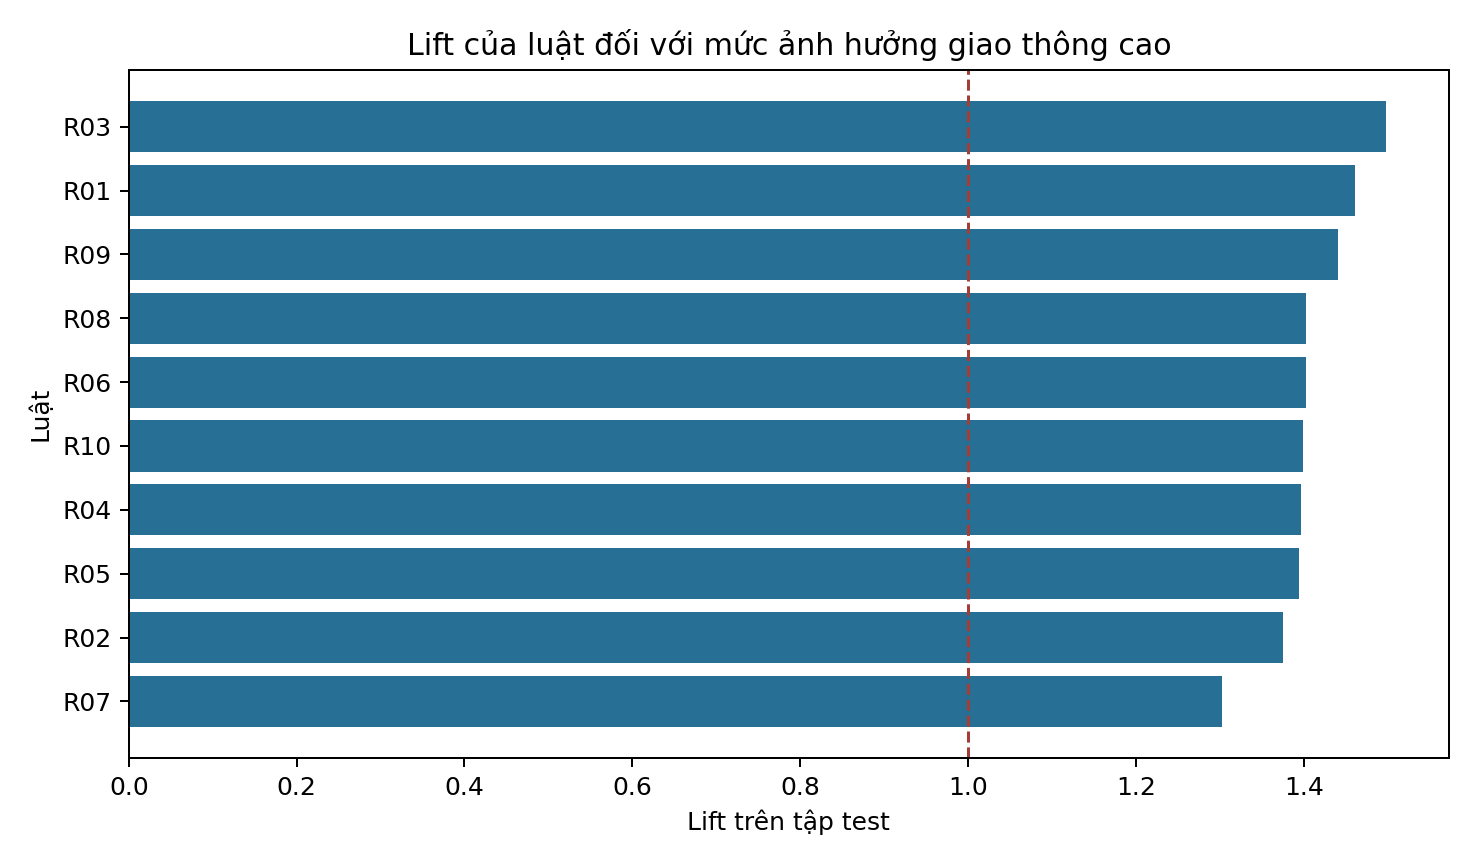

,rule_id,dimension,stratum,n_stratum,n_rule_group,n_comparison_group,severe_rate_rule,severe_rate_comparison,observed_rate_difference,model_risk_rule,model_risk_comparison,model_risk_difference,eligible_main_stratum
0,R01,Source,Source1,9146,397,8749,7.81%,4.32%,3.49%,0.200892,0.138232,6.27%,True
1,R01,Source,Source2,6481,248,6233,52.82%,34.70%,18.12%,0.280972,0.225268,5.57%,True
3,R01,State,CA,11965,581,11384,24.44%,15.79%,8.65%,0.233391,0.168896,6.45%,True
14,R02,Source,Source1,9146,480,8666,5.00%,4.44%,0.56%,0.141607,0.140915,0.07%,True
15,R02,Source,Source2,6481,352,6129,49.43%,34.59%,14.84%,0.268429,0.225044,4.34%,True
17,R02,State,CA,11965,645,11320,22.64%,15.85%,6.79%,0.192038,0.170888,2.12%,True
18,R02,State,TX,4035,206,3829,29.61%,21.62%,7.99%,0.198938,0.188306,1.06%,True
27,R03,Source,Source1,9146,429,8717,5.36%,4.43%,0.93%,0.157451,0.140140,1.73%,True
28,R03,Source,Source2,6481,312,6169,54.81%,34.41%,20.39%,0.259480,0.225777,3.37%,True
30,R03,State,CA,11965,637,11328,24.96%,15.72%,9.24%,0.201260,0.170384,3.09%,True


Đã lưu bảng trung tâm: C:\Study\DataMining\data_mining_project\nhom-3-do-an\artifacts\rules_model_test.csv


In [5]:
rules_model_test, rules_stratified = integrate_rules_and_model(rules_train, test_transactions, predictions)

integration_columns = [
    'rule_id', 'antecedents', 'n_test_covered', 'coverage_test',
    'severe_rate_test', 'severe_rate_comparison', 'lift_test',
    'risk_severe_model_mean', 'risk_severe_model_comparison', 'model_risk_difference',
    'recall_severe_in_rule', 'false_negative_severe_in_rule',
    'n_eligible_main_strata', 'n_positive_main_strata', 'relation'
]
display(rules_model_test[integration_columns].style.format({
    'coverage_test': '{:.2%}',
    'severe_rate_test': '{:.2%}',
    'severe_rate_comparison': '{:.2%}',
    'lift_test': '{:.3f}',
    'risk_severe_model_mean': '{:.2%}',
    'risk_severe_model_comparison': '{:.2%}',
    'model_risk_difference': '{:.2%}',
    'recall_severe_in_rule': '{:.2%}',
}))
display(Image(filename=str(FIGURE_DIR / 'rule_lift_test.png')))
display(rules_stratified[rules_stratified['eligible_main_stratum']].style.format({'severe_rate_rule': '{:.2%}', 'severe_rate_comparison': '{:.2%}', 'observed_rate_difference': '{:.2%}', 'model_risk_difference': '{:.2%}'}))

assert rules_model_test['n_test_covered'].gt(0).all()
assert rules_model_test['rule_id'].is_unique
assert set(rules_stratified['rule_id']) == set(rules_model_test['rule_id'])
print('Đã lưu bảng trung tâm:', ARTIFACT_DIR / 'rules_model_test.csv')

## 5. Bàn giao cho các phần tiếp theo

- Bước tiếp theo dùng `model_predictions_baseline.csv` và `rules_model_test.csv` để phân tích false negatives và so sánh Balanced Random Forest.
- `data_bias_audit.csv` và `rules_stratified_robustness.csv` là điều kiện bắt buộc khi chọn evidence cards; kết quả gộp một mình chưa đủ.
- Bảng rules-model cùng kết quả nâng cao là đầu vào để lập evidence cards; không được xem mỗi dòng là insight hoàn chỉnh.
- Các con số dùng trong báo cáo phải lấy trực tiếp từ artifact/notebook, không gõ lại thủ công.
- Kết luận nhân quả không thuộc phạm vi thiết kế này.